#  k-NN & SVM Classification  
### Distance Metrics, Choosing k, and SVM Hyperplanes & Kernels  

---

##  Overview

We’ll explore two major classification algorithms:
1. **k-Nearest Neighbors (k-NN)**
2. **Support Vector Machine (SVM)**

We’ll learn:
- How **distance metrics** affect k-NN  
- How to **choose k**  
- How **SVM hyperplanes** and **kernels** work  
- And visualize decision boundaries with real demos


In [ ]:
# Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

In [ ]:
from ipywidgets import interact, Dropdown

In [ ]:
# Load dataset
df = sns.load_dataset("iris")
df.head()


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## 1. Understanding k-Nearest Neighbors (k-NN)

**Concept:**  
k-NN is a **lazy learning algorithm** that makes predictions based on the majority class of the **k nearest data points** in the training set.

**Key hyperparameters:**
- `k`: number of neighbors  
- `metric`: distance measure (e.g., Euclidean, Manhattan)

**Steps:**
1. Compute distance of test point from all training points.  
2. Pick the `k` closest neighbors.  
3. Assign the majority label among them.


In [ ]:
# Encode target labels (string → numeric)
le = LabelEncoder()
df['species'] = le.fit_transform(df['species'])

# Choose only 2 features for easy visualization
X = df[['sepal_length', 'petal_length']].values
y = df['species'].values

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Standardize (important for distance & SVM)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


##  2. Distance Metrics Comparison

Let’s see how **distance metric** affects classification:
- **Euclidean distance (L2)**: Straight-line distance  
- **Manhattan distance (L1)**: Sum of absolute differences


The **distance metric** determines how the "closeness" between two points is measured.  
Common choices include:

###  Euclidean Distance (L₂ Norm)
The straight-line distance between two points in n-dimensional space.

$$
d(p, q) = \sqrt \sum_{i=1}^{n} (p_i - q_i)^2
$$

---

###  Manhattan Distance (L₁ Norm)
Also called *City Block Distance* — it measures distance as the sum of absolute differences along each dimension.

$$
d(p, q) = \sum_{i=1}^{n} |p_i - q_i|
$$


---

**When to use:**
- **Euclidean** → when all features have similar scales and importance.  
- **Manhattan** → when features are sparse or when you want to reduce the impact of outliers.


In [ ]:
# Try two distance metrics
metrics = ['euclidean', 'manhattan']

for m in metrics:
    knn = KNeighborsClassifier(n_neighbors=5, metric=m)
    knn.fit(X_train, y_train)
    acc = knn.score(X_test, y_test)
    print(f"Metric: {m:10s} | Accuracy: {acc:.3f}")


Metric: euclidean  | Accuracy: 0.889
Metric: manhattan  | Accuracy: 0.911



- The **Manhattan distance** gives **higher accuracy (0.911)** than the Euclidean distance (0.889).
- This indicates that measuring distance as the **sum of absolute differences (L₁ norm)** works better for this dataset.

**Reason:**
- The Iris dataset features (like sepal length, petal length) have **different scales and spreads**, even after standardization.
- **Manhattan distance** is **less sensitive to outliers** and **handles axis-aligned variations** better.
- **Euclidean distance** emphasizes larger differences (since it squares differences), which can **overweight** certain features.

---

 **Conclusion:**  
For this dataset, **Manhattan distance** is the better choice because it provides **more robust classification performance** and **higher accuracy** for k-NN.


##  3. Choosing the Optimal k

Too small `k` → sensitive to noise  
Too large `k` → over-smooths boundaries

Let’s find best `k` by cross-validation style testing.


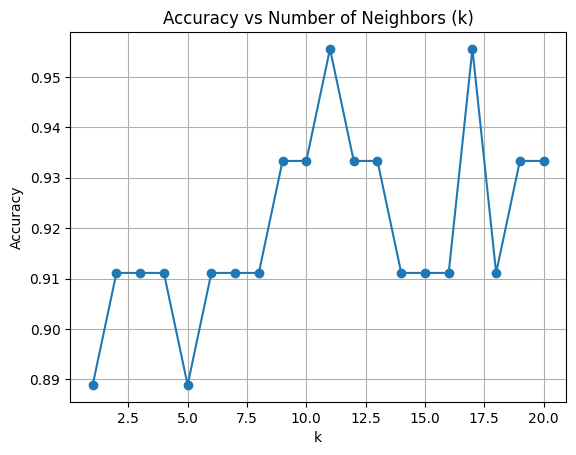

In [ ]:
k_values = range(1, 21)
scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    scores.append(knn.score(X_test, y_test))

plt.plot(k_values, scores, marker='o')
plt.title("Accuracy vs Number of Neighbors (k)")
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()


From the plot above, we observe that the **accuracy fluctuates** as the number of neighbors (k) increases.

- The accuracy reaches its **peak around k = 11 and k = 17**, where it achieves the **highest accuracy (~0.96)**.
- For **smaller k values** (like k = 1 or 2), the model tends to **overfit** — it adapts too closely to the training data, leading to higher variance.
- For **larger k values** (like k > 18), the model becomes **too smooth**, misclassifying boundary points due to **underfitting**.

---


An optimal choice is **k = 11 (or 17)** since it gives the **highest accuracy** while maintaining a smoother decision boundary and better generalization.

---

 **Rule of thumb:**  
To start, a good heuristic is:  
$$
k \approx \sqrt{N}
$$
where \( N \) is the number of training samples.


In [ ]:
print("Number of training samples:", len(X_train))
print("Recommended k (≈ sqrt(N)):", int(np.sqrt(len(X_train))))


Number of training samples: 105
Recommended k (≈ sqrt(N)): 10


The Iris dataset has 150 samples total (50 per class × 3 species).

test_size = 0.3 → 30% goes to test → 0.3×150=45 test samples

The remaining 70% (105 samples) go to training:

150−45=105 training samples

Therefore:$$N_{training} = 105 $$

So, if you apply the rule of thumb for selecting k:

$$ k≈\sqrt N= \sqrt 105≈10.2 $$

That aligns perfectly with our observation — k = 11 gives the best accuracy.

##  4. Visualizing k-NN Decision Boundaries

Let’s visualize how k-NN classifies regions in 2D feature space.


In [ ]:

def plot_decision_boundary(model, X, y, title):
    h = 0.02
    # Define grid limits
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    # Create mesh grid
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    # Predict on mesh grid
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot decision boundary
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')

    # Use seaborn to add hue for true labels
    sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y,
                    palette='deep', s=60, edgecolor='k')

    plt.title(title)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.legend(title="Class")
    plt.show()


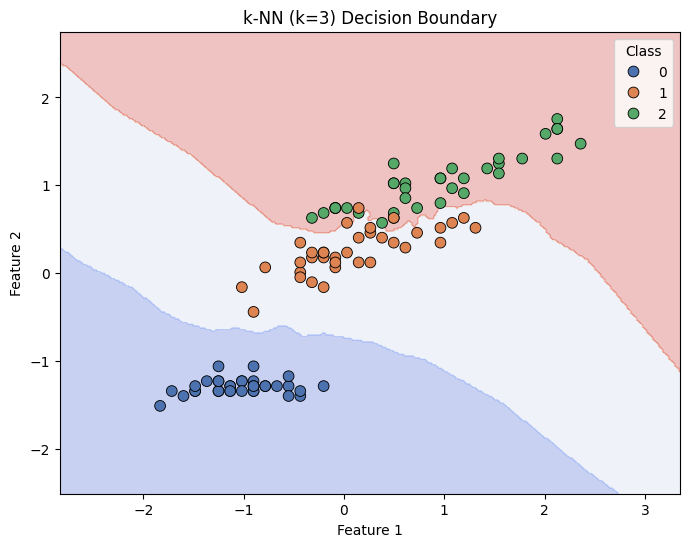

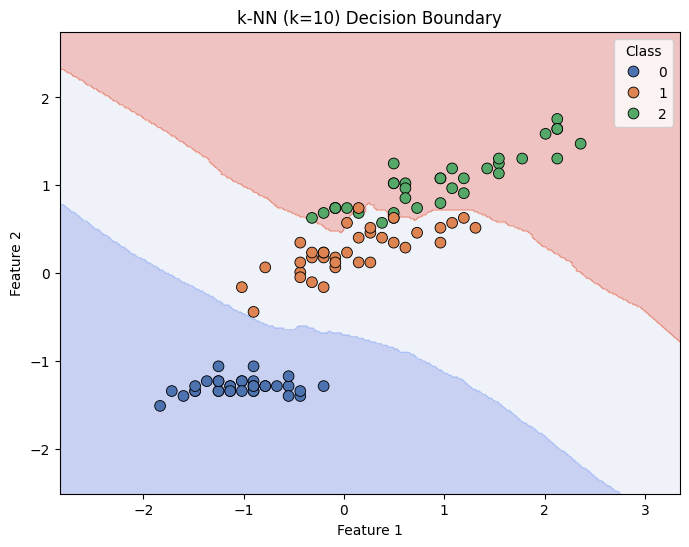

In [ ]:
# k = 3 and k = 10 comparison
for k in [3, 10]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    plot_decision_boundary(knn, X_train, y_train, f"k-NN (k={k}) Decision Boundary")

These plots show how the **k-Nearest Neighbors (k-NN)** classifier divides the feature space into regions corresponding to three classes (0, 1, and 2).


###   k = 3
- **k = 3** means each prediction is made by looking at the **3 nearest neighbors** of a point.  
- The **decision boundary** is relatively **complex and wavy**, showing more local variations.  
- With smaller \( k \), the model is **more sensitive to noise** and may **overfit** the data.  
- It fits the training points closely, which may reduce generalization performance.

###   k = 10
- **k = 10** means the classifier considers **10 nearest neighbors** before deciding the class.  
- The decision boundary is **smoother and simpler**.  
- Larger \( k \) values make the model **less sensitive to noise**, reducing overfitting.  
- However, if \( k \) is too large, it can **underfit**, ignoring local patterns.


##  Summary of the Effect of k

| Parameter | Small \( k \) (e.g., 3) | Large \( k \) (e.g., 10) |
|------------|--------------------------|----------------------------|
| **Decision Boundary** | Complex | Smooth, generalized |
| **Bias** | Low | High |
| **Variance** | High | Low |
| **Risk** | Overfitting | Underfitting |

## Key Takeaway

- **Lower k →** More flexible, fits training data closely, risk of overfitting.  
- **Higher k →** Smoother boundary, better generalization, risk of underfitting.  
- The best \( k \) is usually chosen via **cross-validation** to balance bias and variance.


##  5. Support Vector Machine (SVM)

**Concept:**
SVM tries to find the **optimal hyperplane** that separates data points of different classes **with maximum margin**.

- Works well even in **high-dimensional** spaces.
- Can handle **non-linear** boundaries using **kernels**.

**Common kernels:**
- `linear` → straight line
- `poly` → polynomial boundaries
- `rbf` → radial basis function (nonlinear, default)


##  6. Linear vs RBF Kernel
We’ll visualize how different kernels classify the same data.


In [ ]:
# Interactive function for kernel visualization
def svm_interactive(kernel):
    model = SVC(kernel=kernel, C=1.0, gamma='scale')
    model.fit(X_train, y_train)
    acc = model.score(X_test, y_test)
    print(f"Kernel: {kernel.upper()} | Accuracy: {acc:.3f}")
    plot_decision_boundary(model, X_train, y_train, f"SVM with {kernel.upper()} Kernel")

# Dropdown menu for kernel selection
interact(svm_interactive, kernel=Dropdown(options=['linear', 'poly', 'rbf', 'sigmoid'], value='rbf', description='Kernel:'))


interactive(children=(Dropdown(description='Kernel:', index=2, options=('linear', 'poly', 'rbf', 'sigmoid'), v…

<function __main__.svm_interactive(kernel)>

Kernel: linear  | Accuracy: 0.978


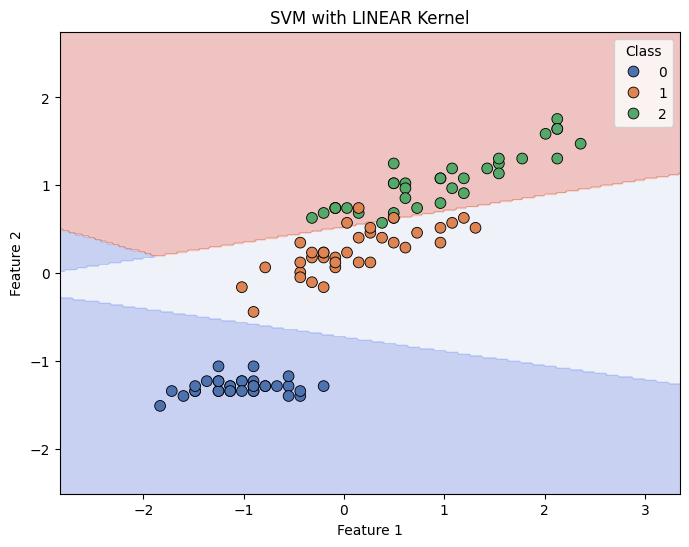

Kernel: rbf     | Accuracy: 0.956


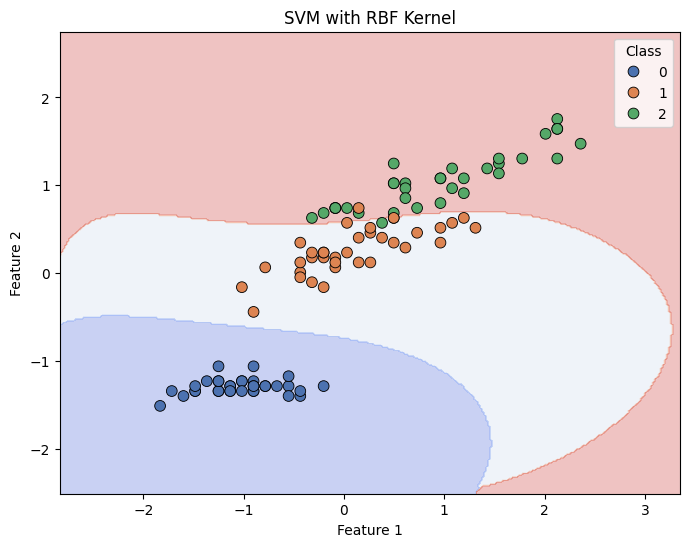

Kernel: poly    | Accuracy: 0.911


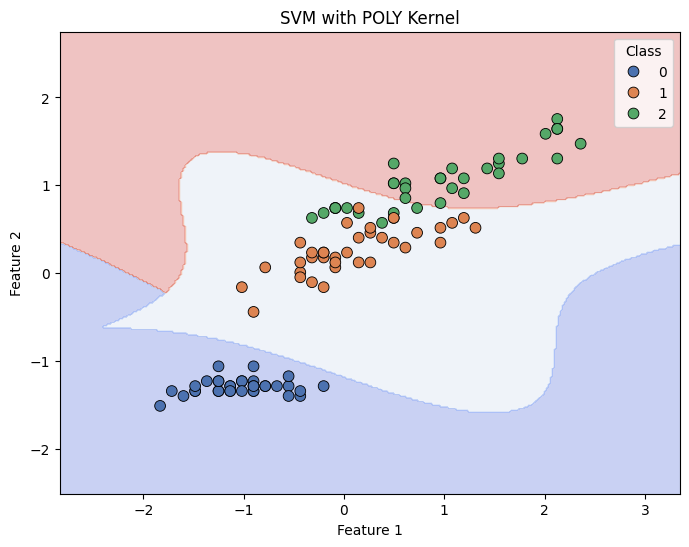

In [ ]:
kernels = ['linear', 'rbf', 'poly']

for k in kernels:
    svm = SVC(kernel=k, gamma='scale', C=1.0)
    svm.fit(X_train, y_train)
    acc = svm.score(X_test, y_test)
    print(f"Kernel: {k:7s} | Accuracy: {acc:.3f}")
    plot_decision_boundary(svm, X_train, y_train, f"SVM with {k.upper()} Kernel")


The **Linear kernel** gives the **highest accuracy**, followed by the **RBF** and then the **Polynomial** kernel.


###  Reasoning:
1. **Linear Kernel (Best Accuracy: 0.978)**
   - The **Iris dataset** features are **mostly linearly separable** (especially for classes like *Setosa*).
   - Hence, a **linear decision boundary** is sufficient to separate the classes effectively.
   - It also avoids unnecessary complexity, reducing the chance of **overfitting**.

2. **RBF Kernel (Accuracy: 0.956)**
   - The **RBF kernel** introduces non-linearity using Gaussian similarity.
   - While powerful, it can sometimes **overfit slightly** when the data is already well-separated linearly.
   - Therefore, its accuracy is slightly **lower than linear** in this case.

3. **Polynomial Kernel (Accuracy: 0.911)**
   - The **Polynomial kernel** maps features to a higher-dimensional space.
   - For datasets that are already mostly linearly separable, this added complexity **does not help** and may cause **overfitting**, leading to lower accuracy.


### **Conclusion:**
For the **Iris dataset**, the classes are largely **linearly separable**, so:
- The **Linear kernel** performs best.  
- The **RBF kernel** performs slightly lower because it models unnecessary non-linearity.  
- The **Polynomial kernel** performs worst due to its complexity and overfitting tendency.

Thus, the **accuracy order — Linear > RBF > Polynomial — is logical and expected.**


## 7. Model Evaluation
Let’s print classification metrics and confusion matrix for best model.


Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       0.88      1.00      0.94        15
           2       1.00      0.87      0.93        15

    accuracy                           0.96        45
   macro avg       0.96      0.96      0.96        45
weighted avg       0.96      0.96      0.96        45



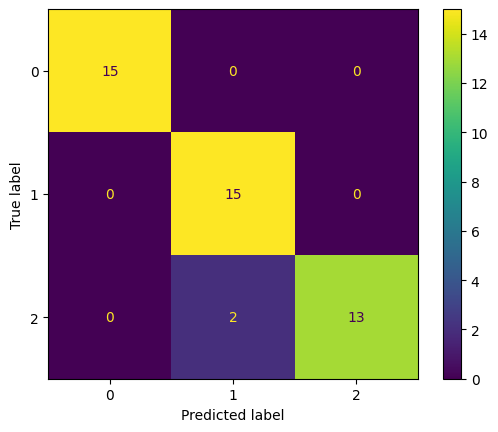

In [ ]:
# Train final model with best-performing kernel (e.g., 'rbf')
svm = SVC(kernel='rbf', C=1.0, gamma='scale')
svm.fit(X_train, y_train)
y_pred = svm.predict(X_test)

print("Classification Report:\n", classification_report(y_test, y_pred))
ConfusionMatrixDisplay.from_estimator(svm, X_test, y_test)
plt.show()


##  Summary

| Concept | Description |
|----------|--------------|
| **k-NN** | Simple, interpretable, no training phase, but slow for large datasets |
| **Distance Metrics** | Control how similarity is measured (Euclidean vs Manhattan) |
| **Choosing k** | Low k → high variance, High k → high bias |
| **SVM** | Finds optimal hyperplane with maximum margin |
| **Kernels** | Allow non-linear classification (RBF, polynomial, etc.) |

---

**Key Takeaway:**  
- Use **k-NN** for smaller datasets or when interpretability matters.  
- Use **SVM** when you need strong performance and complex decision boundaries.


#  Non-linear dataset: Concentric circles

In [ ]:
from sklearn.datasets import make_circles
from sklearn.svm import SVC
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [ ]:
# Generate concentric circles dataset
X_circ, y_circ = make_circles(n_samples=300, noise=0.08, factor=0.5, random_state=42)

In [ ]:
# --- Decision Boundary Function ---
def plot_decision_boundary(model, X, y, title):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(7, 6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, palette='deep', s=60, edgecolor='k')
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.legend(title="Class")
    plt.show()

In [ ]:
# --- Train Linear and RBF SVM ---
svm_linear = SVC(kernel='linear', C=1.0)
svm_rbf = SVC(kernel='rbf', gamma='scale', C=1.0)

svm_linear.fit(X_circ, y_circ)
svm_rbf.fit(X_circ, y_circ)


SVC()

In [ ]:
# --- Accuracy ---
print("Linear Kernel Accuracy:", svm_linear.score(X_circ, y_circ))
print("RBF Kernel Accuracy:", svm_rbf.score(X_circ, y_circ))


Linear Kernel Accuracy: 0.5433333333333333
RBF Kernel Accuracy: 1.0


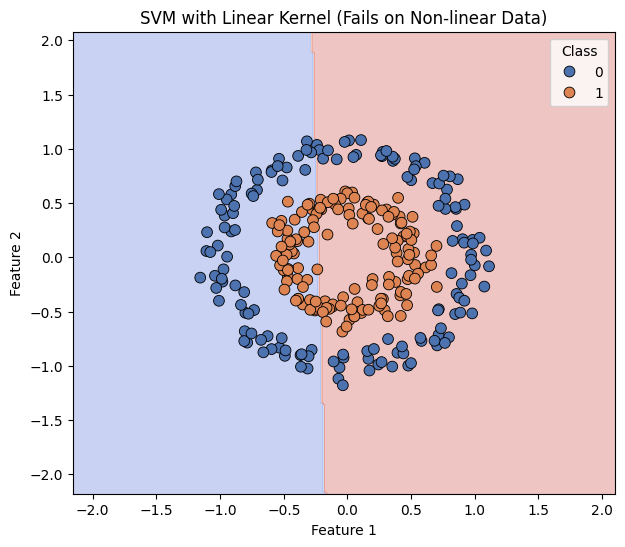

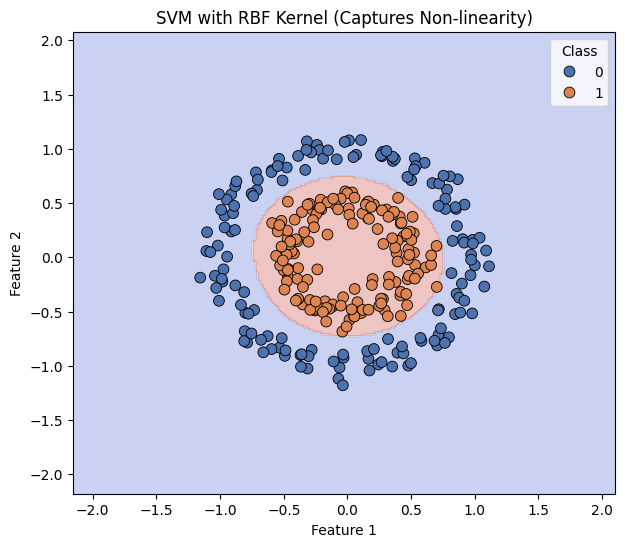

In [ ]:
# --- Plot both ---
plot_decision_boundary(svm_linear, X_circ, y_circ, "SVM with Linear Kernel (Fails on Non-linear Data)")
plot_decision_boundary(svm_rbf, X_circ, y_circ, "SVM with RBF Kernel (Captures Non-linearity)")



- The **Linear Kernel** uses a straight-line decision boundary and **cannot separate** circular data effectively.  
  → Result: **Low accuracy (≈54%)**

- The **RBF Kernel (Radial Basis Function)** creates a **non-linear, curved decision boundary**.  
  → Result: **Perfect accuracy (1.0)** because it correctly models the circular class structure.


###  Key Takeaway

- **Linear kernel →** works for linearly separable data only.  
- **RBF kernel →** handles complex, circular, or curved data effectively.  
- **Kernel trick** allows SVMs to learn **non-linear boundaries** in higher dimensions.
